In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [3]:
df = pd.read_csv("../data_files/historical_execution_data.txt")
df.head()

,V5,V6,V7,V10,V11,V12,V13,V14,V16,V19,V21
0,1,,NORMAN ELI,1,1,19,12,1812,1,1,250
1,1,,WOODS JOHN,44,4,6,2,1814,1,1,616
2,2,,GAMARRA CHARLES,13,1,19,5,1820,1,1,
3,2,,DESAYAS VICTORIANO,1,1,19,5,1820,1,1,
4,2,,NOREAGO FRANCISCO,1,1,30,5,1822,1,1,187


In [4]:
col_to_move = df.pop('V19')
df.insert(1, 'V19', col_to_move)
df.head()

,V5,V19,V6,V7,V10,V11,V12,V13,V14,V16,V21
0,1,1,,NORMAN ELI,1,1,19,12,1812,1,250
1,1,1,,WOODS JOHN,44,4,6,2,1814,1,616
2,2,1,,GAMARRA CHARLES,13,1,19,5,1820,1,
3,2,1,,DESAYAS VICTORIANO,1,1,19,5,1820,1,
4,2,1,,NOREAGO FRANCISCO,1,1,30,5,1822,1,187


In [5]:
df.columns = ['race', 'sex', 'age', 'name', 'crime_com', 'exec_method', 'date_day', 'date_month', 'date_year', 'state', 'off_occ']
df.head()

,race,sex,age,name,crime_com,exec_method,date_day,date_month,date_year,state,off_occ
0,1,1,,NORMAN ELI,1,1,19,12,1812,1,250
1,1,1,,WOODS JOHN,44,4,6,2,1814,1,616
2,2,1,,GAMARRA CHARLES,13,1,19,5,1820,1,
3,2,1,,DESAYAS VICTORIANO,1,1,19,5,1820,1,
4,2,1,,NOREAGO FRANCISCO,1,1,30,5,1822,1,187


In [6]:
# df.info()

In [7]:
# df.dtypes

In [8]:
# df.describe shows all int data
# df['off_occ'].value_counts().head(30)

In [9]:
df = df.sort_values(by='date_year')
# df.head(10)

In [10]:
df['age'] = pd.to_numeric(df['age'], errors='coerce').fillna(0).astype(int)

In [11]:
df['race'] = df['race'].replace({
    '1': 'White',
    '2': 'Black',
    '3': 'Native Am',
    '4': 'Asian-Pac-Il',
    '5': 'Hispanic',
    '6': 'Other',
    ' ': 'Unknown'
    })
# df.head()

In [12]:
df['race'].value_counts()

race
Black           7353
White           6344
Unknown          710
Native Am        362
Hispanic         349
Asian-Pac-Il     147
Other              3
Name: count, dtype: int64

In [13]:
# df['race'].unique()
# df['sex'].unique() finally showed the "third" sex was a space

In [14]:
df['sex'] = df['sex'].replace({'1': 'Male', '2': 'Female', ' ': 'Unknown'})
# df.head()

In [15]:
df['sex'].value_counts()

sex
Male       14750
Female       364
Unknown      154
Name: count, dtype: int64

In [16]:
df['crime_com'] = df['crime_com'].str.strip()

In [17]:
df['crime_com'].unique()

<StringArray>
['18', '43', '30',  '2',  '1',   '', '10', '12', '31',  '9', '44', '40', '16',
  '7', '35',  '4', '36',  '8', '39', '26',  '5', '14', '33', '15', '22', '37',
 '11', '20',  '6', '23', '41', '17', '13', '19', '24', '28', '21', '27', '29',
 '25',  '3']
Length: 41, dtype: str

In [18]:
df['crime_com'] = df['crime_com'].replace({
    '1': 'Murder',
    '2': 'Rape',
    '3': 'Criminal Assault',
    '4': 'HouseBrkng-Burgl',
    '5': 'Horse Stealing',
    '6': 'Consp to Murder',
    '7': 'Treason',
    '8': 'Slave Revolt',
    '9': 'Witchcraft',
    '10': 'Robbery-Murder',
    '11': 'Rape-Murder',
    '12': 'Piracy',
    '13': 'Accessory to Mur',
    '14': 'Desertion',
    '15': 'Robbery',
    '16': 'Arson',
    '17': 'Guerilla Activity',
    '18': 'Spying-Espionage',
    '19': 'Murder-Rape-Rob',
    '20': 'Burg-Att Rape',
    '21': 'Rioting',
    '22': 'Attempted Rape',
    '23': 'Murder-Burglary',
    '24': 'Kidnap-Murder',
    '25': 'Kidnap-Murder-Rob',
    '26': 'Arson-Murder',
    '27': 'Rape-Robbery',
    '28': 'Kidnapping',
    '29': 'Prisn Brk-Kidnap',
    '30': 'Sodmy-Buggry-Bst',
    '31': 'Adultery',
    '33': 'Poisoning',
    '35': 'Concealing Birth',
    '36': 'Unspec Felony',
    '37': 'Aid Runaway Slave',
    '39': 'Counterfeiting',
    '40': 'Attempted Murder',
    '41': 'Forgery',
    '43': 'Theft-Stealing',
    '44': 'Other',
    '': 'Unknown',
})
# df.head()

In [19]:
# df['crime_com'].unique()

In [20]:
# df['exec_method'].unique()
df['exec_method'] = df['exec_method'].str.strip()

In [21]:
df['exec_method'].unique()

<StringArray>
['4', '1', '15', '', '10', '6', '14', '13', '8', '11', '5', '2', '3']
Length: 13, dtype: str

In [22]:
df['exec_method'] = df['exec_method'].replace({
    '1': 'Hanging',
    '2': 'Electrocution',
    '3': 'Asphyxiation-Gas',
    '4': 'Shot',
    '5': 'Injection',
    '6': 'Pressing',
    '8': 'Break on Wheel',
    '10': 'Burned',
    '11': 'Hung in Chains',
    '13': 'Bludgeoned',
    '14': 'Gibbetted',
    '15': 'Other',
    '': 'Unknown'
})
# df.head()

In [23]:
# df['name'].unique()
# how to replace names that might be spaces?

In [24]:
# DON'T NEED THIS RIGHT NOW BUT COULD BE USEFUL IN FUTURE
#  df['name'] = df['name'].str.strip().str.replace(r'\s+', ' ', regex=True)

In [25]:
# shows all info if string contains certain text in specific column
# df[df['name'].str.contains('')]
# df[df['off_occ'].str.contains('689')]

In [26]:
df['off_occ'] = df['off_occ'].str.strip().str.replace(r'\s+', ' ', regex=True)

In [27]:
df['off_occ'] = df['off_occ'].replace({
    '610': 'Slave',
    '355': 'Laborer',
    '236': 'Farm Hand',
    '241': 'Farmer',
    '160': 'Convict',
    '224': 'Ex Convict',
    '237': 'Farm Laborer',
    '465': 'Parolee',
    '417': 'Miner',
    '616': 'Soldier',
    '272': 'Gangster',
    '220': 'Escaped Convict',
    '591': 'Seaman',
    '173': 'Criminal',
    '475': 'Pirate',
    '654': 'Tenant Farmer',
    '271': 'Gang Member',
    '108': 'Carpenter',
    '328': 'Housewife',
    '689': 'Truck Driver',
    '': 'Unknown'})

# '222': 'Escaped Prisoner'
# '574': 'Sailor'

In [28]:
# df['off_occ'].unique()

In [29]:
# df['off_occ'].value_counts()

In [30]:
# df.head()

In [31]:
# df['state'].unique()
# df['state'].dtype
df['state'] = df['state'].astype(str)
df['state'].dtype

<StringDtype(storage='python', na_value=nan)>

In [32]:
df['state'] = df['state'].replace({
'1': 'AL',
'2': 'AK',
'4': 'AZ',
'5': 'AR',
'6': 'CA',
'8': 'CO',
'9': 'CT',
'10': 'DE',
'11': 'W.D.C.',
'12': 'FL',
'13': 'GA',
'15': 'HI',
'16': 'ID',
'17': 'IL',
'18': 'IN',
'19': 'IA',
'20': 'KS',
'21': 'KY',
'22': 'LA',
'23': 'ME',
'24': 'MD',
'25': 'MA',
'26': 'MI',
'27': 'MN',
'28': 'MS',
'29': 'MO',
'30': 'MT',
'31': 'NE',
'32': 'NV',
'33': 'NH',
'34': 'NJ',
'35': 'NM',
'36': 'NY',
'37': 'NC',
'38': 'ND',
'39': 'OH',
'40': 'OK',
'41': 'OR',
'42': 'PA',
'44': 'RI',
'45': 'SC',
'46': 'SD',
'47': 'TN',
'48': 'TX',
'49': 'UT',
'50': 'VT',
'51': 'VA',
'53': 'WA',
'54': 'WV',
'55': 'WI',
'56': 'WY'})

In [33]:
# df['state'].unique()

In [34]:
df.head()

,race,sex,age,name,crime_com,exec_method,date_day,date_month,date_year,state,off_occ
13062,White,Male,0,KENDALL GEORGE,Spying-Espionage,Shot,,,1608,VA,166
13063,White,Male,0,FRANK DANIELL,Theft-Stealing,Hanging,1,3,1622,VA,331
13064,White,Male,0,CORNISH RICHARD,Sodmy-Buggry-Bst,Hanging,,,1624,VA,Unknown
13065,White,Male,21,HAYLE THOMAS,Rape,Hanging,6,,1626,VA,Unknown
5795,White,Male,40,BILLINGTON JOHN,Murder,Hanging,30,9,1630,MA,Unknown


In [35]:
# df[df['exec_method'] == 'Hanging']

In [36]:
# df[df["off_occ"] == "Slave"][["crime_com", "exec_method"]].value_counts()

In [37]:
df[(df["off_occ"] == "Slave") & (df["exec_method"] == "Injection")]

,race,sex,age,name,crime_com,exec_method,date_day,date_month,date_year,state,off_occ
14470,Black,Male,0,NATHAN (WILSON),Murder,Injection,1,5,1821,WV,Slave


In [38]:
df[df['exec_method'] == 'Injection']

,race,sex,age,name,crime_com,exec_method,date_day,date_month,date_year,state,off_occ
14470,Black,Male,0,NATHAN (WILSON),Murder,Injection,1,5,1821,WV,Slave
12952,Black,Male,40,BROOKS CHARLIE JR,Murder,Injection,7,12,1982,TX,Unknown
12953,White,Male,29,AUTRY JAMES,Robbery-Murder,Injection,14,3,1984,TX,Parolee
12954,White,Male,39,O BRYAN RONALD,Murder,Injection,31,3,1984,TX,448
9407,White,Male,54,HUTCHINS JAMES,Murder,Injection,16,3,1984,NC,Laborer
...,...,...,...,...,...,...,...,...,...,...,...
14914,White,Male,42,CANNON RANDALL EUGENE,Kidnap-Murder-Rob,Injection,23,7,2002,OK,Unknown
14915,White,Male,51,FREDERICK EARL ALEXANDER SR.,Murder,Injection,30,7,2002,OK,819
15172,Black,Male,25,JONES T.J.,Robbery-Murder,Injection,8,8,2002,TX,164
15258,White,Male,35,PATTERSON JAMES EARL,Murder-Rape-Rob,Injection,14,3,2002,VA,Unknown


In [39]:
df[(df["off_occ"] == "Slave") & (df["race"] == "White")]

,race,sex,age,name,crime_com,exec_method,date_day,date_month,date_year,state,off_occ
7509,White,Male,0,QUACO (THONG),Slave Revolt,Hanging,,,1712,NY,Slave
7518,White,Male,0,MINGO (BARBERIE),Slave Revolt,Hanging,15,4,1712,NY,Slave
7524,White,Male,0,SAM (FAUCONNIER),Slave Revolt,Hanging,18,4,1712,NY,Slave
7520,White,Male,0,TOM (DEHOUVE),Slave Revolt,Hanging,15,4,1712,NY,Slave
7519,White,Male,0,QUACO (VAN DAM),Slave Revolt,Hanging,15,4,1712,NY,Slave
7521,White,Male,0,TOM (ROOSEVELT),Slave Revolt,Burned,15,4,1712,NY,Slave
7507,White,Male,0,CAESAR (MORIN),Slave Revolt,Burned,,,1712,NY,Slave
7523,White,Male,0,KITTO (GOUVERNEUR),Slave Revolt,Hanging,18,4,1712,NY,Slave
7522,White,Male,0,QUASI (VAN DAM),Slave Revolt,Hanging,15,4,1712,NY,Slave
7506,White,Female,0,SARAH (PELS),Slave Revolt,Hanging,,,1712,NY,Slave


In [40]:
# exec_trends = df.groupby('date_year')["exec_method"].count()
# exec_trends

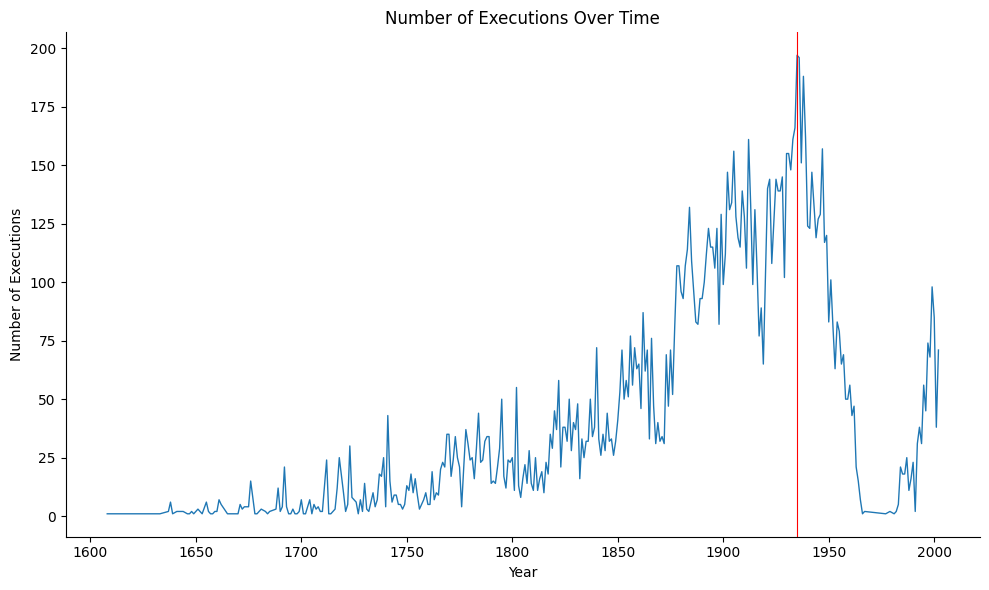

In [41]:
exec_trends = df.groupby('date_year')["exec_method"].count()

plt.figure(figsize=(10,6))
plt.plot(
    exec_trends.index,
    exec_trends.values,
    linewidth = .99)

plt.xlabel('Year')
plt.ylabel('Number of Executions')
plt.title('Number of Executions Over Time')

ax = plt.gca()
ax1 = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Can you have multiple vertical lines?
ax.axvline(
    1935,
    color = "red",
    linewidth = .8
)

plt.tight_layout()
plt.show()

In [42]:
df['date_year'].value_counts().idxmax()

np.int64(1935)

In [43]:
df[df['date_year'] == '1935'][['crime_com', 'exec_method']]

,crime_com,exec_method


In [44]:
# exec_method_counts = df["exec_method"].value_counts().sort_values(ascending=False)
# exec_method_counts

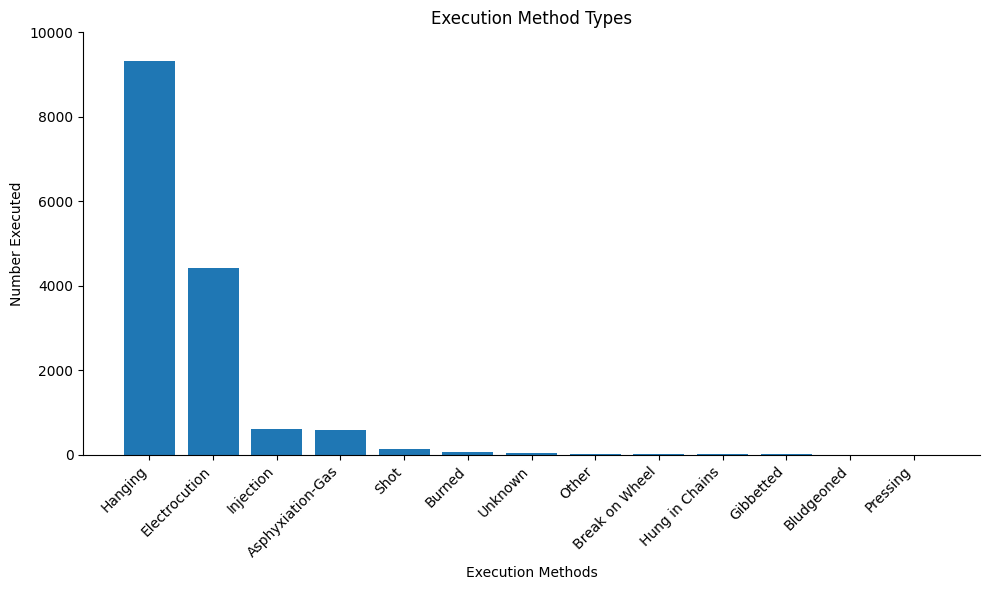

In [45]:
# create cleaned exec method df dropping "Unknown"

exec_method_counts = df["exec_method"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(10,6))
plt.bar(exec_method_counts.index, exec_method_counts.values)
plt.xticks(rotation=45, ha="right")

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xlabel('Execution Methods')
plt.ylabel('Number Executed')
plt.title('Execution Method Types')

plt.ylim(0, 10000)
plt.tight_layout()
plt.show()

In [46]:
df_age_clean = df.drop(df[df['age'] == 0].index)
df_age_clean

,race,sex,age,name,crime_com,exec_method,date_day,date_month,date_year,state,off_occ
13065,White,Male,21,HAYLE THOMAS,Rape,Hanging,6,,1626,VA,Unknown
5795,White,Male,40,BILLINGTON JOHN,Murder,Hanging,30,9,1630,MA,Unknown
5802,White,Male,18,HACKETT WILLIAM,Sodmy-Buggry-Bst,Hanging,10,12,1641,MA,593
5803,White,Male,17,GRAUNGER THOMAS,Sodmy-Buggry-Bst,Hanging,,,1642,MA,593
5805,White,Female,18,LATHAM MARY,Adultery,Hanging,21,3,1643,MA,Housewife
...,...,...,...,...,...,...,...,...,...,...,...
14915,White,Male,51,FREDERICK EARL ALEXANDER SR.,Murder,Injection,30,7,2002,OK,819
14648,White,Female,54,BLOCK LYNDA LYON,Murder,Electrocution,10,5,2002,AL,Unknown
15172,Black,Male,25,JONES T.J.,Robbery-Murder,Injection,8,8,2002,TX,164
15258,White,Male,35,PATTERSON JAMES EARL,Murder-Rape-Rob,Injection,14,3,2002,VA,Unknown


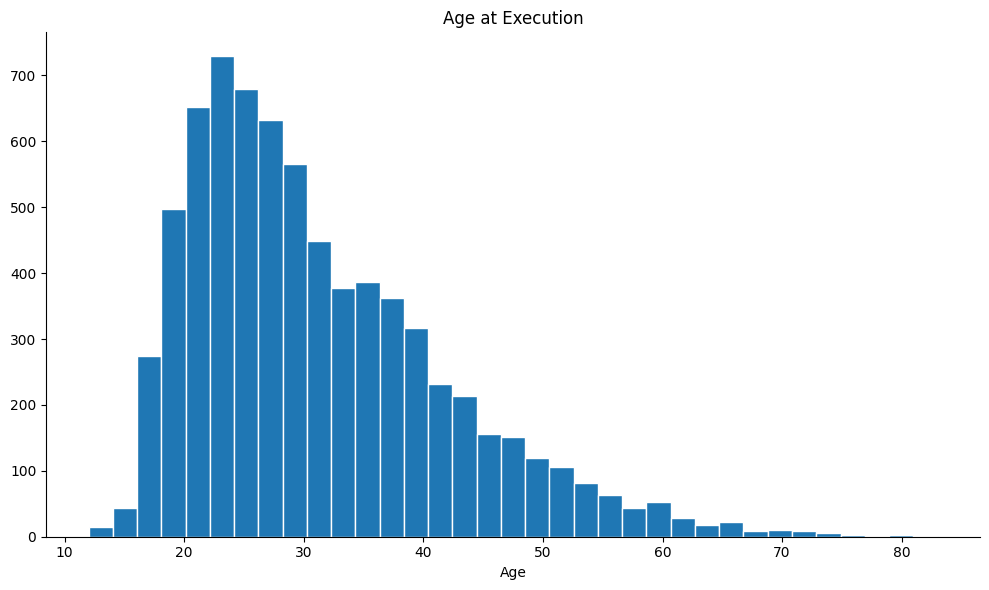

In [47]:
plt.figure(figsize=(10,6))
plt.hist(
    df_age_clean["age"],
    edgecolor = "white",
    bins = 35
)

plt.xlabel("Age")
plt.title("Age at Execution")

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [48]:
df_age_clean['age'].describe()

count    7311.000000
mean       31.450007
std        10.566819
min        12.000000
25%        23.000000
50%        29.000000
75%        38.000000
max        83.000000
Name: age, dtype: float64

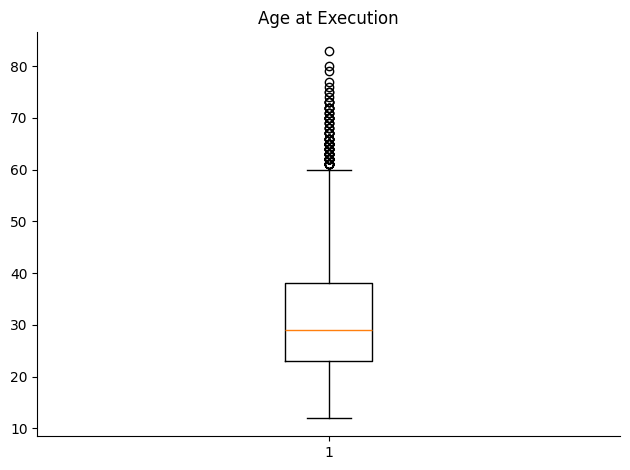

In [49]:
plt.boxplot(df_age_clean['age'])
plt.title('Age at Execution')

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [50]:
df.duplicated().sum()

np.int64(238)

In [51]:
off_occ_clean = df.drop(df[df['off_occ'] == 'Unknown'].index)
# off_occ_clean

<Axes: xlabel='off_occ'>

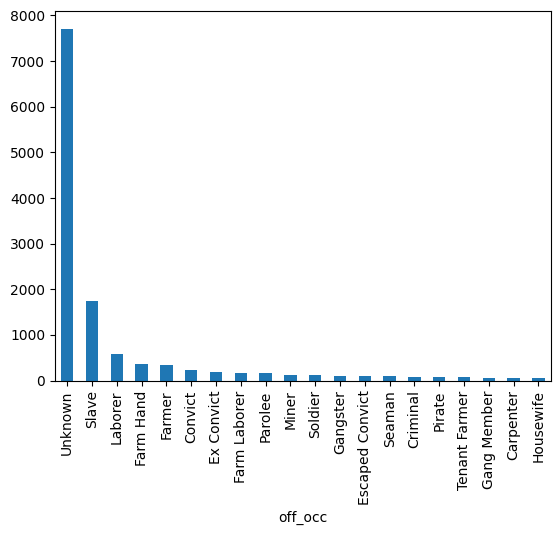

In [52]:
df['off_occ'].value_counts().head(20).plot.bar()

In [53]:
off_occ_clean2 = off_occ_clean['off_occ'].value_counts().head(20)
# off_occ_clean2

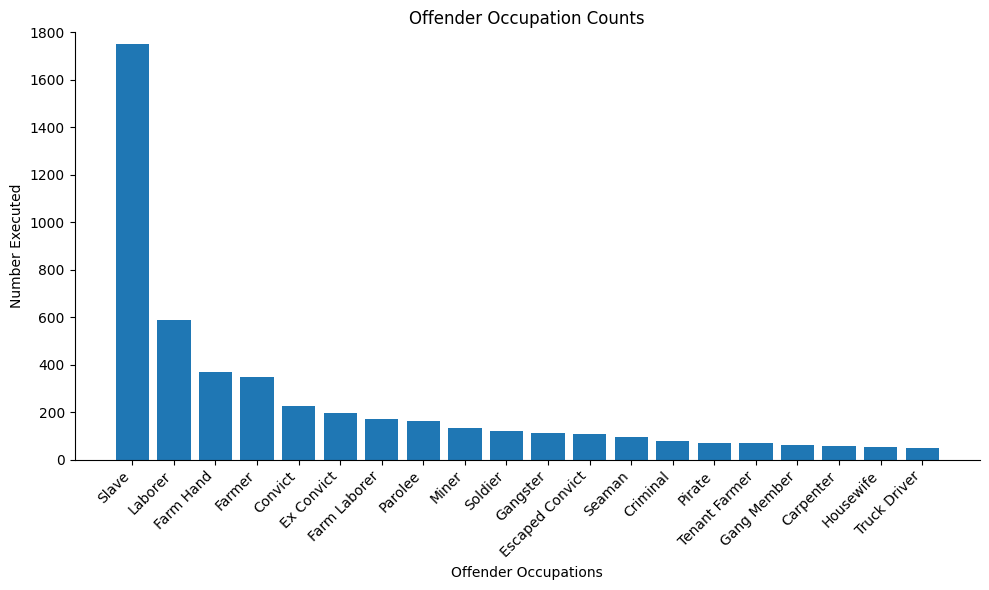

In [54]:
plt.figure(figsize=(10,6))
plt.bar(off_occ_clean2.index, off_occ_clean2.values)
plt.xticks(rotation=45, ha="right")

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xlabel('Offender Occupations')
plt.ylabel('Number Executed')
plt.title('Offender Occupation Counts')

plt.ylim(0, 1800)
plt.tight_layout()
plt.show()